<a href="https://colab.research.google.com/github/abdullahalmusabbir/Deep-Learning-Project/blob/main/Intel_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Importing Libraries**

In [1]:
import tensorflow as tf
from tensorflow import keras
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image_dataset_from_directory
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

# **2. Importing Kaggle Dataset**

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


# **3. Loading Data**

In [3]:
train_dir = path + '/seg_train/seg_train'
val_dir = path + '/seg_test/seg_test'
test_dir = path + '/seg_pred/seg_pred'

**3.1 Scaling Data**

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1.0/255.0
)

In [5]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256, 256),
    batch_size=32,
    class_mode='sparse'
)
val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(256, 256),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


# **4. Visualizing Data**

**4.1 Training data**

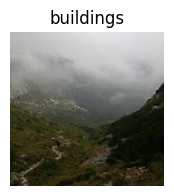

In [6]:
images, labels = next(train_data)
class_names = {v: k for k, v in train_data.class_indices.items()}

plt.figure(figsize=(2, 2))
plt.imshow(images[1])
label_index = np.argmax(labels[1])
label_name = class_names[label_index]
plt.title(f"{label_name}")
plt.axis('off')

plt.show()

**4.2 Labels Integer Based**

In [7]:
train_data[0][1]

array([0., 3., 5., 2., 4., 2., 4., 5., 1., 4., 1., 4., 1., 5., 1., 4., 1.,
       5., 3., 0., 2., 3., 0., 1., 1., 1., 3., 2., 4., 2., 4., 3.],
      dtype=float32)

# **5. CNN Model Building**

**5.1 Architecture**

In [8]:
model = tf.keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape = (256,256,3)),
    keras.layers.MaxPooling2D(2, 2),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Flatten(),

    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(6, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    58,982,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,079,238 (225.37 MB)

 Trainable params: 59,079,238 (225.37 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

**5.2 Model Training**

In [ ]:
model.fit(train_data, epochs = 20, validation_data = val_data, batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
  5/439 ━━━━━━━━━━━━━━━━━━━━ 39:28 5s/step - accuracy: 0.1389 - loss: 5.9859

**However, the accuracy can be further increased if we train our model for more epochs. The accuracy will continue to improve, and the loss will decrease, without the fear of overfitting**

# **6. Model Testing**

# 6.1 Testing On Unseen Data

In [ ]:
img_path = path + '/seg_pred/seg_pred/10004.jpg'

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
img = image.load_img(img_path, target_size=(256, 256))
img_array = image.img_to_array(img)


img_array = img_array / 256.0

print(img_array.shape)

In [ ]:
plt.figure(figsize=(3,3))
plt.imshow(img_array)
plt.title('street')
plt.show()

In [ ]:
class_names = {
    'building': 0,
    'forest': 1,
    'glacier': 2,
    'mountain': 3,
    'sea': 4,
    'street': 5,
}

In [ ]:
img_array = np.expand_dims(img_array, axis=0)
prediction = model.predict(img_array)

In [ ]:
predicted_class_index = np.argmax(prediction)

In [ ]:
for class_name, index in class_names.items():
    if index == predicted_class_index:
        predicted_class_label = class_name
        break
print(predicted_class_label)

# 6.2 Accuracy Comparision

In [ ]:
import matplotlib.pyplot as plt

history = model.history.history

plt.figure(figsize=(8, 6))
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# 6.3 Loss Comaprision

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# **7. Model Export**

In [ ]:
#model.save('/content/my_model.h5')

In [ ]:
#from google.colab import files
#files.download('/content/my_model.h5')